# Exercise 4 Solutions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from scipy.stats import norm
import seaborn as sns
from scipy.stats import ttest_ind

## (a) Compute the calibration of a normal-based CI for the mean under lognormal data.

**What is a confidence interval for the mean?**

Given a sample $y_1, \dots, y_n$, the standard normal-based CI for the population mean is:

$$
\left[\; \bar{y} + Q_{\alpha/2}\,\mathrm{SE}_{\bar{y}} \;,\quad \bar{y} + Q_{1-\alpha/2}\,\mathrm{SE}_{\bar{y}} \;\right]
$$

where $\bar{y} = \frac{1}{n}\sum_{i=1}^n y_i$ is the sample mean, $\mathrm{SE}_{\bar{y}} = s / \sqrt{n}$ is its standard error, $s = \sqrt{\frac{1}{n-1}\sum_{i=1}^n (y_i - \bar{y})^2}$ is the sample standard deviation, and $Q_p$ is the $p$-th quantile of the standard normal.

**Intuition:** We are saying the true mean lies within $\pm$ a few standard errors of our sample mean. The z-quantiles control how wide that interval is — a 95% CI uses $Q_{0.025} \approx -1.96$ and $Q_{0.975} \approx 1.96$.

**Where the normality assumption comes in:** This formula is derived assuming the sample mean $\bar{y}$ is approximately normally distributed. By the Central Limit Theorem (CLT), this holds for large $n$ regardless of the data distribution, but for small $n$ the reliability depends on how close the data distribution is to normal. The following code implements this CI:

In [2]:
def ci_mean(y, alpha):
    mean = np.mean(y)
    se = np.std(y, ddof=1) / np.sqrt(len(y))  # standard error
    z_low, z_high = norm.ppf([alpha/2, 1 - alpha/2])  # normal quantiles
    return mean + np.array([z_low, z_high]) * se  # the two CI end-points

**Simulation setup — data generating model:**

We generate data from $y_i \sim \text{LogNormal}(\mu, \sigma)$. This is a natural stress test for the CI: lognormal data is right-skewed, so the normality assumption behind the CI is violated to varying degrees depending on $\sigma$.

The true population mean of a lognormal is $\mathbb{E}[Y] = \exp(\mu + \sigma^2/2)$ — this is what we check whether the CI covers.

We run separate simulations for every combination of:
- **$n \in \{10, 100, 1000\}$** — small to large sample sizes, to see the CLT kick in
- **$\mu \in \{-1, 0, 1\}$** — different location parameters
- **$\sigma \in \{0.1, 1, 2\}$** — low to high skewness; larger $\sigma$ = more asymmetric data

In [ ]:
ns = [10, 100, 1000]
mus = [-1, 0, 1]
sigmas = [0.1, 1, 2]

We want to test calibration across multiple confidence levels, not just a single one. A CI at level $1-\alpha$ is **well-calibrated** if it covers the true mean exactly $(1-\alpha) \times 100\%$ of the time. The four values below correspond to 50%, 67%, 80%, and 90% CIs:

In [ ]:
alphas = [0.5, 1/3, 0.2, 0.1]

For each combination of $(n, \mu, \sigma, \alpha)$, we repeat the experiment `n_sim` times. Each repetition draws a fresh sample and checks whether the CI covers the truth. The fraction of successes across all repetitions is our **estimated coverage**. More simulations = less Monte Carlo noise in that estimate:

In [ ]:
n_sim = 10_000

**Main simulation loop:**

The logic for each $(n, \mu, \sigma)$ combination is:
1. Compute the **true mean** $\exp(\mu + \sigma^2/2)$ — this is our fixed target.
2. Repeat `n_sim` times:
   - Draw a fresh lognormal sample of size $n$.
   - For each $\alpha$, compute the normal-based CI and check if it contains the true mean.
3. Divide the success counts by `n_sim` to get the **empirical coverage** for each CI level.

The result is stored as a long-form DataFrame, with one row per $(n, \mu, \sigma, \alpha)$ combination, making it easy to plot and compare.

In [3]:
np.random.seed(394)

records = []
for n, mu, sigma in product(ns, mus, sigmas):
    true_mean = np.exp(mu + sigma**2 / 2)
    counts = np.zeros(len(alphas))

    for _ in range(n_sim):
        y = np.random.lognormal(mean=mu, sigma=sigma, size=n)  # draw a sample y of size n
        for i, alpha in enumerate(alphas):
            low, high = ci_mean(y, alpha)       # for each alpha, form a normal‐based CI via ci_mean
            counts[i] += (low < true_mean) & (true_mean < high)  # increment a counter if that CI covers the true mean

    coverage = counts / n_sim * 100  # convert counts to percentage coverage
    for alpha, cov in zip(alphas, coverage):
        records.append({
            'n': n,
            'mu': mu,
            'sigma': sigma,
            'ci_level': int(round((1-alpha)*100)),
            'coverage': cov
        })

df = pd.DataFrame(records)

**Plotting nominal vs. actual coverage:**

Each subplot corresponds to a $(\mu, \sigma)$ pair. Within each subplot, we plot the **nominal CI level** (x-axis) against the **empirical coverage** (y-axis) for each sample size $n$. The dashed diagonal line is the ideal: if the CI is perfectly calibrated, all points should fall exactly on it. Points below the diagonal indicate undercoverage (the CI is too narrow); points above indicate overcoverage (too wide).

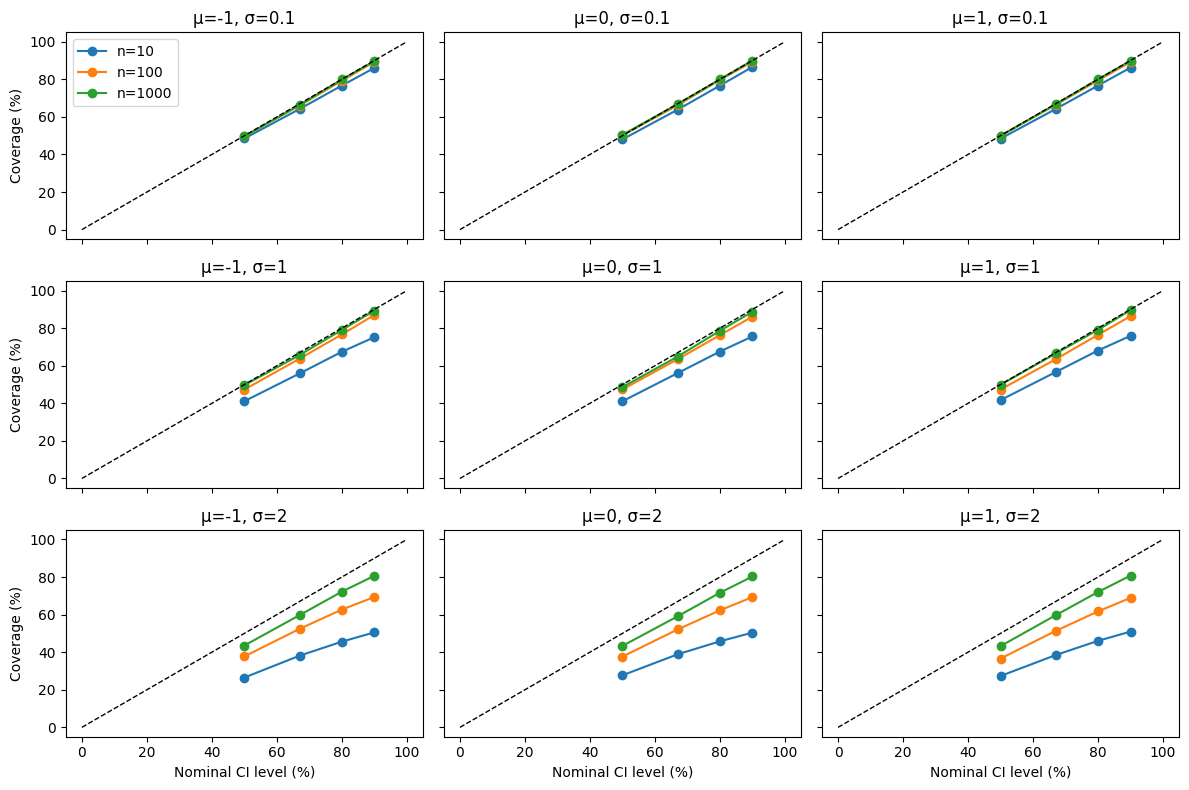

In [4]:
fig, axes = plt.subplots(len(sigmas), len(mus), figsize=(12, 8), sharex=True, sharey=True)
for i, sigma in enumerate(sigmas):
    for j, mu in enumerate(mus):
        ax = axes[i, j]
        sub = df[(df.sigma==sigma)&(df.mu==mu)]
        for n in ns:
            sd = sub[sub.n==n]
            ax.plot(sd.ci_level, sd.coverage, '-o', label=f'n={n}')
        ax.plot([0,100],[0,100],'k--', linewidth=1)
        ax.set_title(f'μ={mu}, σ={sigma}')
        if i==len(sigmas)-1:
            ax.set_xlabel('Nominal CI level (%)')
        if j==0:
            ax.set_ylabel('Coverage (%)')
        if i==0 and j==0:
            ax.legend()
plt.tight_layout()
plt.show()


**Results:**

- **Effect of $\sigma$ (skewness):** For small $\sigma$ (e.g. 0.1), the lognormal is nearly symmetric and the CI is well-calibrated even at small $n$. As $\sigma$ grows, the data becomes increasingly right-skewed, the CLT approximation breaks down, and the CI systematically **undercovers** — it is narrower than it should be, so the true mean falls outside it more often than the nominal level implies.

- **Effect of $n$ (sample size):** Larger $n$ brings the empirical coverage closer to the diagonal across all $\sigma$ values. This is the CLT at work: as $n$ grows, the sample mean becomes approximately normal regardless of the underlying distribution, making the normal-based CI valid.

- **Effect of $\mu$:** Coverage is largely unaffected by $\mu$. The CI is built around $\bar{y}$ and its width scales with the data spread, so the absolute location of the distribution does not matter for calibration.

**Key takeaway:** The normal-based CI for the mean is only reliable for lognormal data when either the sample is large enough for the CLT to apply, or $\sigma$ is small enough that the skewness is negligible.

## (b) Compute the p-curve for the t-test for unequal variances under a normal and lognormal scenario where the variances are (1) same or (2) different.

We have two independent groups $X$ and $Y$ and want to test whether their population means are equal. The hypotheses are:

$$
H_0: \mu_x = \mu_y \qquad \text{(the means are the same)}
$$
$$
H_1: \mu_x \neq \mu_y \qquad \text{(the means differ)}
$$

**What we want to check:** If we simulate data *under $H_0$* (i.e. with truly equal means), a well-calibrated test should produce p-values that are $\text{Uniform}(0, 1)$. Any deviation from uniformity — especially a spike near zero — means the test has inflated false positive rates and cannot be trusted at the stated significance level. We check this for different data distributions and variance settings.

**Normal scenario:**
$$
x_i \sim \mathcal{N}(\mu,\, \sigma_x), \qquad y_i \sim \mathcal{N}(\mu,\, \sigma_y), \qquad i = 1, \dots, n.
$$

**Lognormal scenario:**  
The mean of a $\text{LogNormal}(\mu_x, \sigma_x)$ variable is $\exp\!\left(\mu_x + \sigma_x^2 / 2\right)$. To enforce $\mathbb{E}[X] = \mathbb{E}[Y] = e^{\mu}$ (the null hypothesis of equal means), we absorb the variance-induced shift into the location parameter:
$$
x_i \sim \text{LogNormal}\!\left(\mu_x = \mu - \tfrac{\sigma_x^2}{2},\;\sigma_x\right), \qquad
y_i \sim \text{LogNormal}\!\left(\mu_y = \mu - \tfrac{\sigma_y^2}{2},\;\sigma_y\right).
$$

Under both models, the population variances are equal precisely when $\sigma_x = \sigma_y$.

For the simulation we fix $n = 50$ and $\mu = 0$, and vary $\sigma_x, \sigma_y \in \{0.1, 1, 2\}$ across both likelihood types.

In [5]:
n_sim = 10_000
n     = 50
mu    = 0
likelihoods = ['normal', 'lognormal']
sigmas = [0.1, 1, 2]

##  Welch’s *t*-test

Suppose you have two independent samples  
$$
\{x_i\}_{i=1}^{n_1},\quad \{y_j\}_{j=1}^{n_2}
$$

with unknown means ($\mu_x,\mu_y$) and (possibly) different variances \($\sigma_x^2,\sigma_y^2$).  

1. **Estimate the difference of means**  
   $$
     \Delta \;=\;\bar x - \bar y,
     \qquad
     \bar x = \frac1{n_1}\sum_{i=1}^{n_1}x_i,\quad
     \bar y = \frac1{n_2}\sum_{j=1}^{n_2}y_j.
   $$

2. **Compute the standard error**  
   $$
     \mathrm{SE}(\Delta)
     = \sqrt{\frac{s_x^2}{n_1} \;+\;\frac{s_y^2}{n_2}},
     \quad
     s_x^2 = \frac{1}{n_1-1}\sum_{i=1}^{n_1}(x_i-\bar x)^2,\quad
     s_y^2 = \frac{1}{n_2-1}\sum_{j=1}^{n_2}(y_j-\bar y)^2.
   $$

3. **Form the t–statistic**  
   $$
     t
     = \frac{\bar x - \bar y}{\displaystyle\sqrt{\tfrac{s_x^2}{n_1} + \tfrac{s_y^2}{n_2}}}.
   $$

4. **Approximate degrees of freedom** (Welch–Satterthwaite)  
   $$
     \nu
     = \frac{\bigl(\tfrac{s_x^2}{n_1} + \tfrac{s_y^2}{n_2}\bigr)^{2}}
            {\frac{s_x^4}{n_1^2\,(n_1-1)} \;+\;\frac{s_y^4}{n_2^2\,(n_2-1)}}.
   $$

5. **Two‐sided p-value**  
   $$
     p = 2\bigl[1 - F_{t_\nu}\bigl(|t|\bigr)\bigr],
   $$
   where ($F_{t_\nu}$) is the CDF of the Student-t distribution with ($\nu$) degrees of freedom.

  In most statistical packages you can just call a single function—e.g. in SciPy:


In [ ]:
from scipy.stats import ttest_ind
#pval = ttest_ind(x, y, equal_var=False).pvalue

Once we define our simulation grid, we can simulate the data, compute and store the p-value
of the Welch t-test for unequal variances.

In [6]:
# the parameter grid

grid = pd.DataFrame(
    product(range(n_sim), likelihoods, sigmas, sigmas),
    columns=['sim', 'lik', 'sigma_x', 'sigma_y']
)
grid['n'] = n
grid['mu'] = mu
grid['p_value'] = np.nan

# run simulations

for idx, row in grid.iterrows():
    if row.lik == 'normal':
        x = np.random.normal(row.mu, row.sigma_x, row.n)
        y = np.random.normal(row.mu, row.sigma_y, row.n)
    else:
        x = np.random.lognormal(mean=row.mu - row.sigma_x**2/2, sigma=row.sigma_x, size=row.n)
        y = np.random.lognormal(mean=row.mu - row.sigma_y**2/2, sigma=row.sigma_y, size=row.n)

    pval = ttest_ind(x, y, equal_var=False).pvalue
    grid.at[idx, 'p_value'] = pval


In [7]:
def plot_hist(data, title):
    g = sns.FacetGrid(data, row='sigma_x', col='sigma_y',
                      margin_titles=True, sharey=False)
    g.map_dataframe(sns.histplot, x='p_value', stat='density',
                    binwidth=0.05, color='lightgray', edgecolor='black')
    for ax in g.axes.flat:
        ax.axhline(1, ls='--', color='black')  # uniform(0,1) density reference
    g.set_axis_labels('p-value', 'Density')
    g.fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

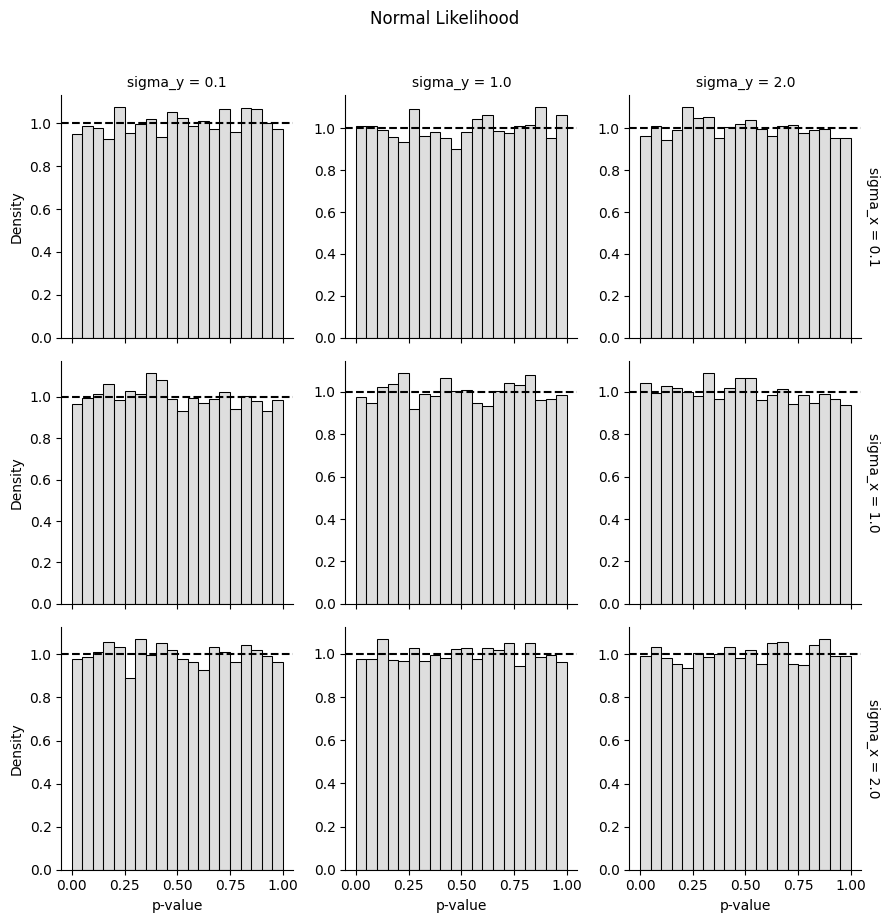

In [ ]:
plot_hist(grid[grid.lik == 'normal'], title='Normal Likelihood')

Under the normal likelihood, the simulated p-values are approximately $\text{Uniform}(0, 1)$ across **all** combinations of $\sigma_x$ and $\sigma_y$, including cases where the two variances differ. This confirms that Welch's t-test achieves valid Type I error control for normal data regardless of variance heterogeneity — precisely its design goal.

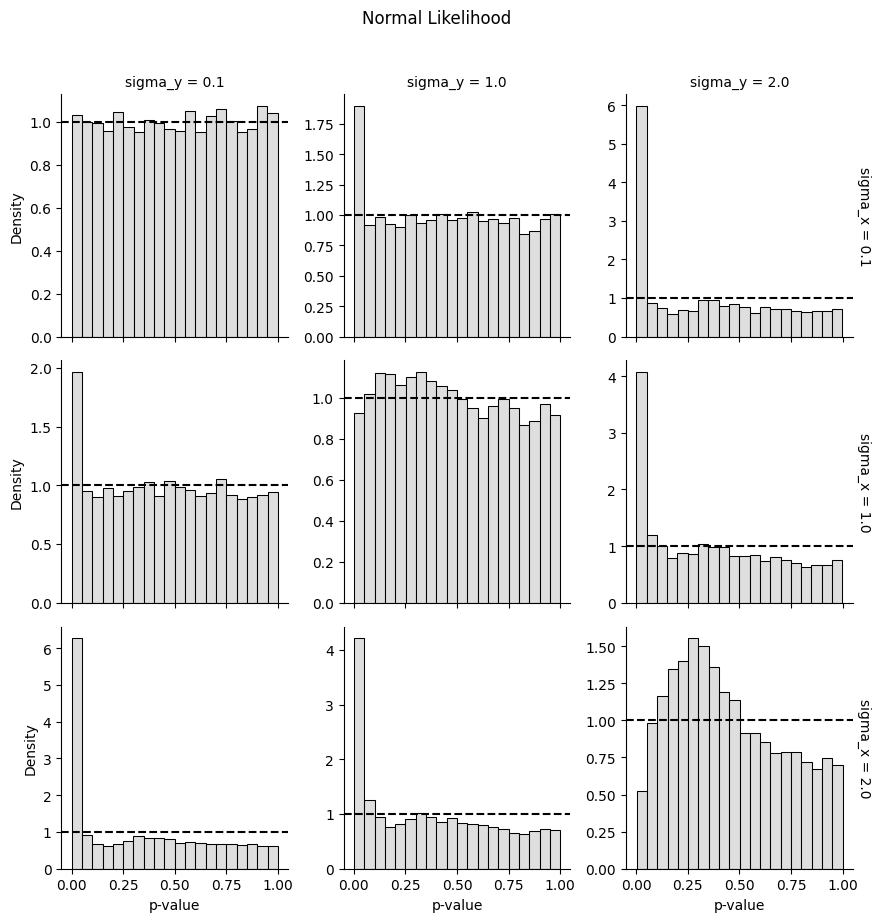

In [9]:
plot_hist(grid[grid.lik == 'lognormal'], title='LogNormal Likelihood')

Under the lognormal likelihood, the simulated p-values are **not** uniform, indicating that the Welch t-test is miscalibrated. Two factors drive the severity:

- **Magnitude of $\sigma$:** Larger $\sigma$ produces greater skewness in the lognormal distribution. The Welch t-test relies on the CLT to justify approximate normality of the sample means; high skewness slows CLT convergence, causing an excess of small p-values (inflated false positives).

- **Equal vs. unequal $\sigma_x$ and $\sigma_y$:**
  - When $\sigma_x = \sigma_y$, both groups are drawn from identically shaped distributions. The resulting symmetry keeps the null distribution of the t-statistic centred, which partially limits miscalibration — especially for small $\sigma$, where the lognormal is nearly normal.
  - When $\sigma_x \neq \sigma_y$, the two samples have different skewness and spread. This asymmetry distorts the null distribution of the t-statistic more severely, producing a pronounced spike of p-values near zero.

Overall, miscalibration is worst when at least one $\sigma$ is large **and** the two $\sigma$ values differ, and least severe when both $\sigma$ values are small.